# Demo 1: Noise Generator

We gonna show how to simultate our cantilever's thermal noise in this demo

In [16]:
import sys
from pathlib import Path
repo_root = Path.cwd().parent   # demo/data → demo → browniansim/
sys.path.insert(0, str(repo_root))
import browniansim as fc

import numpy as np
import matplotlib.pyplot as plt

# simulating the noise

We want to simulate the noise under different temperature


## setting up parameters

In [17]:
T_l = [1,4,70,275]  #Temperture(k)
kb = 1.38 * 10**-23
k = 2.7 * 10**-3
w0 = 2 * np.pi * 8169.7
std_shotN = 0.1*10**-9
Q = 15000

dtau = 0.05 * 2 * np.pi  # Our sampling rate is about 200kHz, w0 is about 8k, so about 20 times larger
dw = np.array([])  # We need to set the effective radial frequency for each set, w_eff = 1+dw, and the real radial frequency w(t) = w0*w_eff = w0*(1+dw)


n = 1000.3  # Number of cycles in each pulse
X0_0 = [1, 0]  # Initial displacement and velocity for simulation
p0 = np.pi / 2

dw_l_ana = np.zeros(int(n * 2 * np.pi / dtau))  # w = 1+dw
dw_l_sim = np.zeros((int(n * 2 * np.pi / dtau),4))  # w = 1+dw

sig_analytical = fc.analytical_sol_ringdown(X0_0, Q, dw_l_ana, dtau, p0)  # While generating the analytical trajectory, we also generate the correct time series
sig_analytical[:, 0] = sig_analytical[:, 0] / w0
t = sig_analytical[:, 0]

In [18]:
r = 100# suppression ratio of the initial condition comparing to the equlibrium state
N = 128# number of trials to be simulated for different temperature
noise_negon_l = [[] for _ in range(len(T_l))]

for i,T in enumerate(T_l):
    print(f"Simulating temperature {T}K")
    for j in range(N):
        if j%56==0:
            print(j//56)
        theta = np.random.rand()*2*np.pi
        X0_0 = [np.sqrt(kb*T*2/k)*np.cos(theta)*(0.8+0.4*np.random.rand())/r,np.sqrt(kb*T*2/k)*np.sin(theta)*(0.5+np.random.rand())/r]
        noise_negon = fc.brownian_simulator(T, k, Q, dtau, X0_0, dw_l_sim, std_shotN, withShotNoise=False)

        noise_negon_l[i].append(noise_negon)








Simulating temperature 1K
0
1
2
Simulating temperature 4K
0
1
2
Simulating temperature 70K
0
1
2
Simulating temperature 275K
0
1
2


# Display results of several single simulations

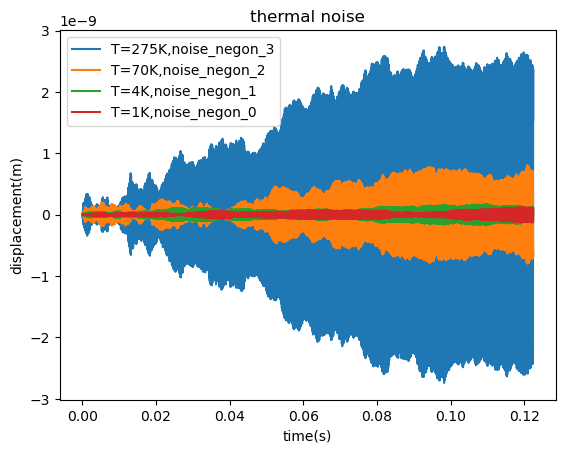

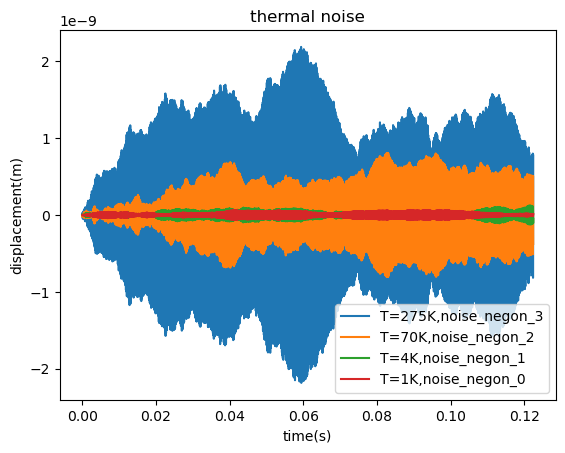

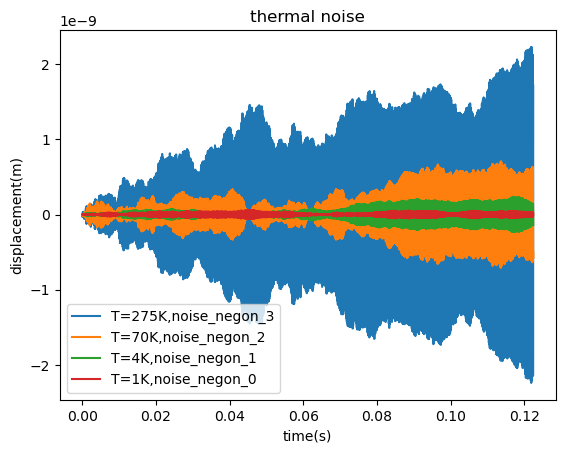

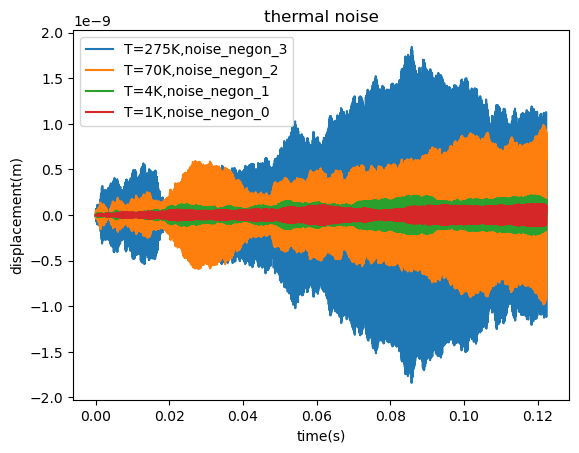

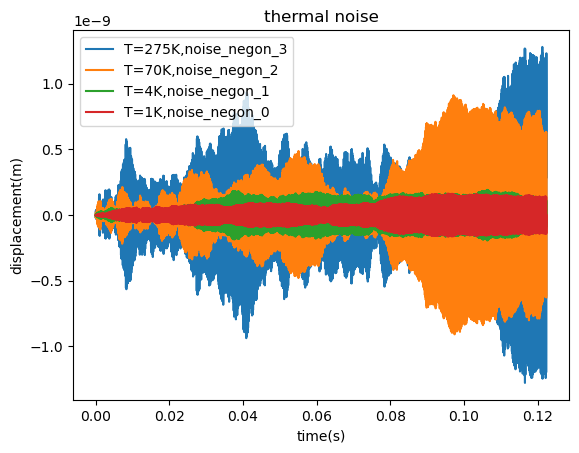

In [19]:

import matplotlib.pyplot as plt

for j in range(44,49):
    for i, T in reversed(list(enumerate(T_l))):
        plt.plot(t,noise_negon_l[i][j][:,0],label='T='+str(T)+'K,'+"noise_negon_"+str(i))
    plt.xlabel("time(s)")
    plt.ylabel("displacement(m)")
    plt.title("thermal noise")
    plt.legend()
    plt.show()

# Averaging the squared noise values (essentially reflecting the variance dynamics)

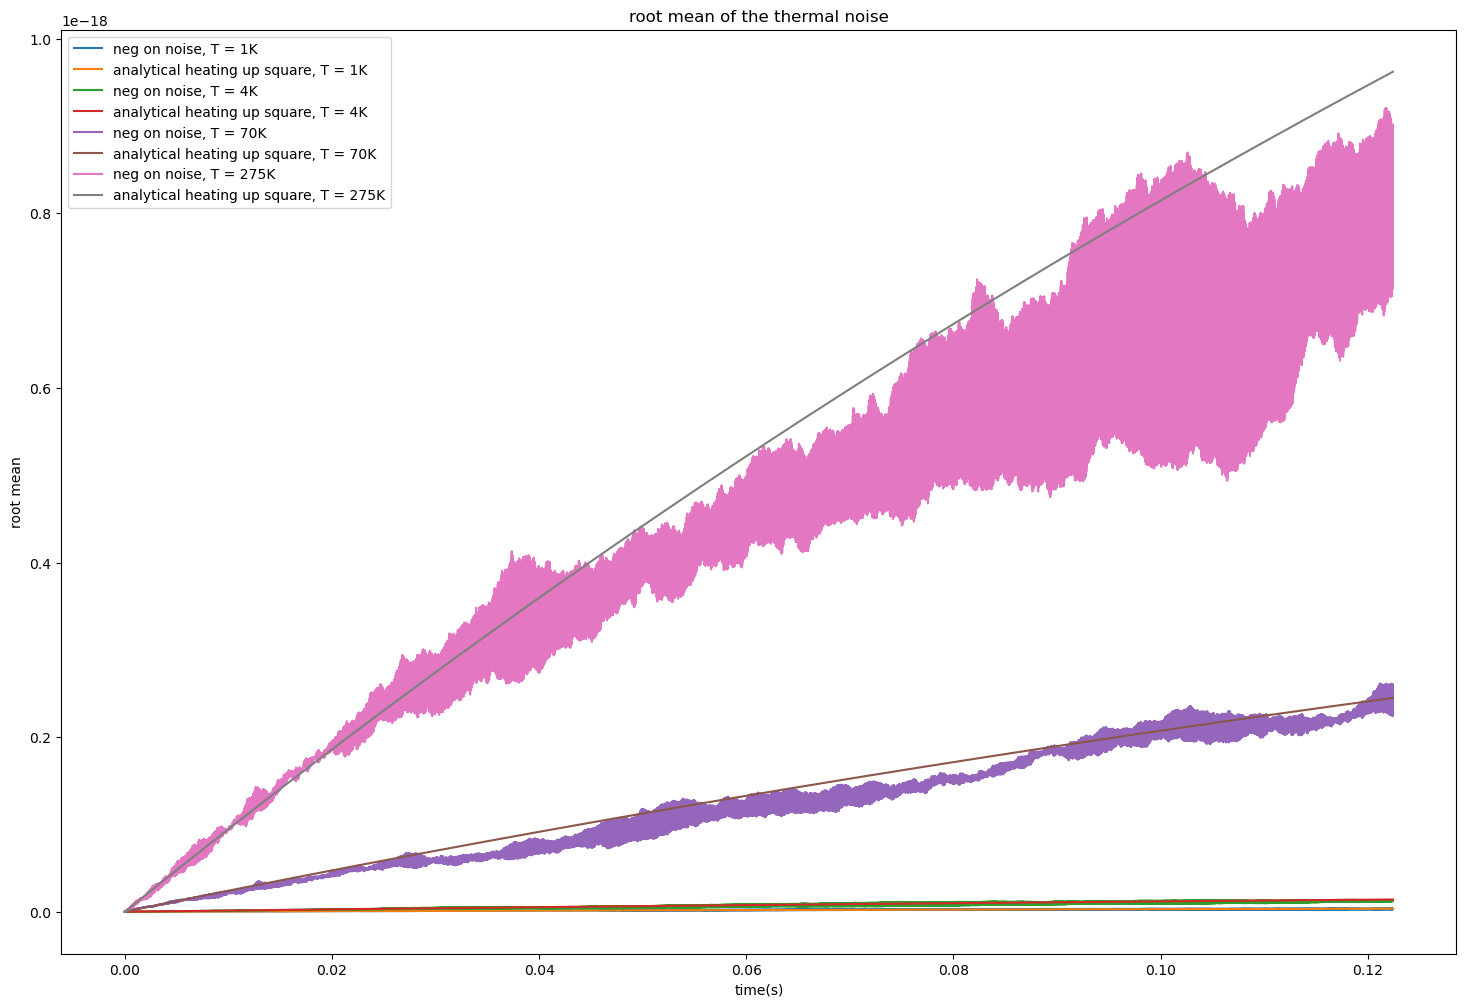

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))
for i, T in enumerate(T_l):
    plt.plot(t,np.mean(np.array(noise_negon_l[i])**2,axis=0)[:,0],label="neg on noise, T = "+str(T)+'K')
    y_negon = kb * T*2 / k  * (1 - np.exp(-t *w0/ Q)) 
    plt.plot(t,y_negon,label="analytical heating up square, T = "+str(T)+'K')
plt.legend()
plt.title("root mean of the thermal noise")
plt.ylabel("root mean")
plt.xlabel("time(s)")
plt.show()

C:\Users\top_c\AppData\Local\Temp\ipykernel_29496\661451812.py:9: RuntimeWarning: divide by zero encountered in log10
  y_negon =np.log10( kb * T*2 / k  * (1 - np.exp(-t *w0/ Q)) )


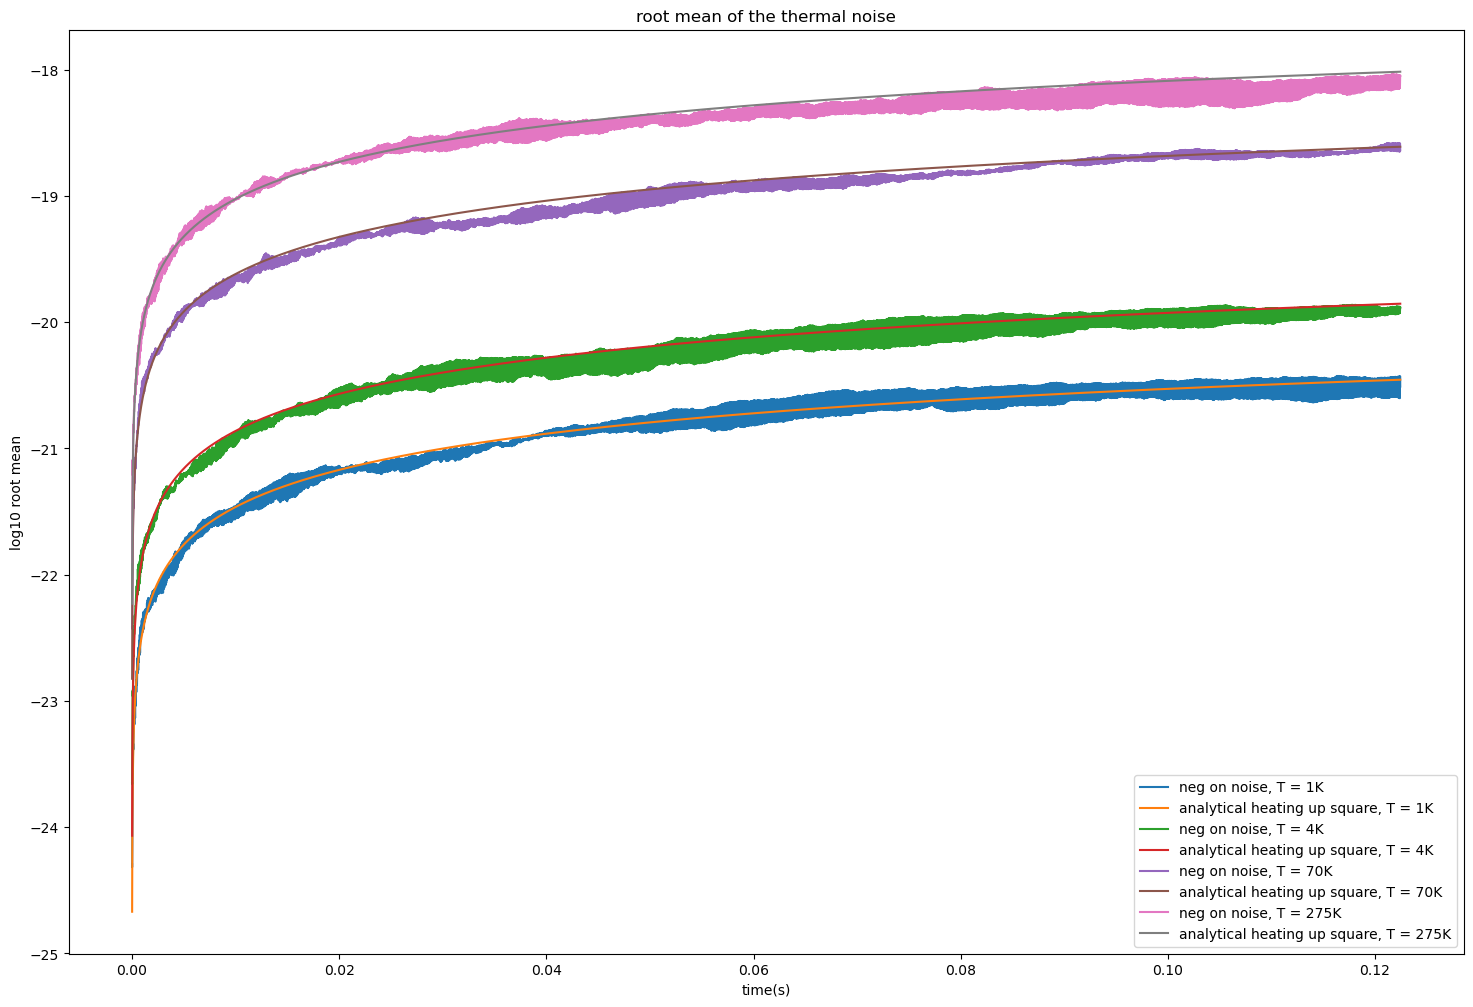

In [22]:
import matplotlib.pyplot as plt



plt.figure(figsize=(18, 12))
for i, T in enumerate(T_l):
    plt.plot(t,np.log10(np.mean(np.array(noise_negon_l[i])**2,axis=0)[:,0]),label="neg on noise, T = "+str(T)+'K')

    y_negon =np.log10( kb * T*2 / k  * (1 - np.exp(-t *w0/ Q)) )
    plt.plot(t,y_negon,label="analytical heating up square, T = "+str(T)+'K')
plt.legend()
plt.title("root mean of the thermal noise")
plt.ylabel("log10 root mean")
plt.xlabel("time(s)")
plt.show()